In [1]:
pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
#libraries
import spacy
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import pipeline
from collections import defaultdict

**Load a Dickens Text**

In [3]:
# a tale of two cities
url = "https://www.gutenberg.org/cache/epub/98/pg98.txt"
text = requests.get(url).text

**Preprocess & Load into spaCy**

In [14]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 9000000000000000000

doc = nlp(text[3000:])

**Extract Sentences with Mental State Verbs**

In [15]:
theory_of_mind_verbs = [
    "think", "believe", "know", "wonder", "suppose", "realize",
    "realise","imagine", "guess", "doubt", "feel", "consider",
    "hope","wish", "suspect", "predict", "expect", "assume", "fear"
]

matching_sentences = []

for sent in doc.sents:
    if any(token.lemma_ in theory_of_mind_verbs for token in sent):
        matching_sentences.append(sent.text)

**Count Mental State Verb Frequency**

In [16]:
verb_counts = Counter()

for sent in doc.sents:
    for token in sent:
        if token.lemma_ in theory_of_mind_verbs:
            verb_counts[token.lemma_] += 1

print(verb_counts.most_common())

[('know', 408), ('think', 184), ('hope', 100), ('believe', 54), ('feel', 51), ('doubt', 49), ('wish', 41), ('fear', 34), ('suppose', 33), ('expect', 26), ('consider', 23), ('wonder', 19), ('suspect', 15), ('imagine', 10), ('guess', 7), ('assume', 6), ('realise', 2)]


**Visualise Frequency Over Time (Chunk-Based)**

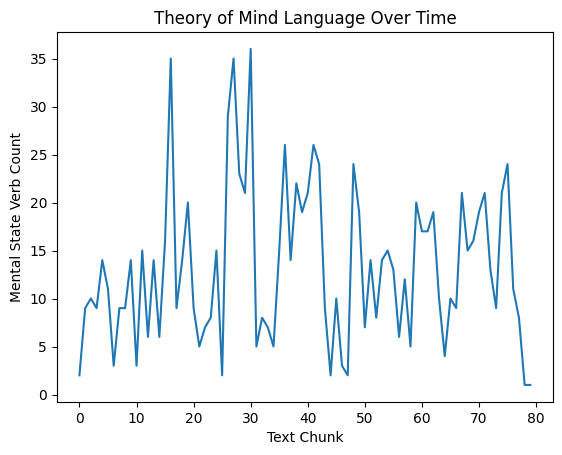

In [17]:
chunk_size = 10000  # adjustments can be made
chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
counts_over_time = []

for chunk in chunks:
    doc = nlp(chunk)
    count = sum(1 for token in doc if token.lemma_ in theory_of_mind_verbs)
    counts_over_time.append(count)

plt.plot(counts_over_time)
plt.xlabel("Text Chunk")
plt.ylabel("Mental State Verb Count")
plt.title("Theory of Mind Language Over Time")
plt.show()

**Track Character Co-occurrence**
To find which characters are associated with mental states.

In [18]:
characters = [
    "Charles Darnay", "Darnay", "Monsieur Darnay",
    "Sydney Carton", "Carton", "Mr. Carton",
    "Lucie Manette", "Lucie", "Miss Manette", "Mrs. Darnay",
    "Dr. Alexandre Manette", "Dr. Manette", "Doctor Manette", "Manette",
    "Jarvis Lorry", "Mr. Lorry",
    "Ernest Defarge", "Monsieur Defarge", "Defarge",
    "Madame Defarge", "Madame", "Mrs. Defarge",
    "Miss Pross", "Pross",
    "Jerry Cruncher", "Mr. Cruncher", "Cruncher", "Jerry",
    "Young Jerry", "Jerry Junior", "Little Jerry",
    "C.J. Stryver", "Mr. Stryver", "Stryver",
    "John Barsad", "Barsad", "Solomon Pross",
    "Roger Cly", "Cly",
    "The Marquis St. Evrémonde", "The Marquis", "Marquis Evrémonde", "Monseigneur",
    "Gabelle",
    "The Vengeance",
    "The Mender of Roads", "Wood-sawyer", "Samson of the Firewood Guillotine",
    "The Seamstress",
    "The Spy",
    "The Public Prosecutor",
    "Jacques One", "Jacques Two", "Jacques Three", "Jacques",
    "Madame Gabelle",
    "Little Lucie", "Lucie Darnay"
]


character_mentalization = {name: 0 for name in characters}

for sent in matching_sentences:
    for name in characters:
        if name in sent:
            character_mentalization[name] += 1

print(character_mentalization)

{'Charles Darnay': 9, 'Darnay': 30, 'Monsieur Darnay': 0, 'Sydney Carton': 5, 'Carton': 31, 'Mr. Carton': 13, 'Lucie Manette': 1, 'Lucie': 26, 'Miss Manette': 14, 'Mrs. Darnay': 0, 'Dr. Alexandre Manette': 0, 'Dr. Manette': 0, 'Doctor Manette': 17, 'Manette': 37, 'Jarvis Lorry': 3, 'Mr. Lorry': 67, 'Ernest Defarge': 0, 'Monsieur Defarge': 2, 'Defarge': 26, 'Madame Defarge': 10, 'Madame': 12, 'Mrs. Defarge': 0, 'Miss Pross': 33, 'Pross': 37, 'Jerry Cruncher': 0, 'Mr. Cruncher': 20, 'Cruncher': 22, 'Jerry': 15, 'Young Jerry': 3, 'Jerry Junior': 0, 'Little Jerry': 0, 'C.J. Stryver': 0, 'Mr. Stryver': 10, 'Stryver': 18, 'John Barsad': 0, 'Barsad': 8, 'Solomon Pross': 0, 'Roger Cly': 0, 'Cly': 2, 'The Marquis St. Evrémonde': 0, 'The Marquis': 0, 'Marquis Evrémonde': 0, 'Monseigneur': 12, 'Gabelle': 1, 'The Vengeance': 0, 'The Mender of Roads': 0, 'Wood-sawyer': 0, 'Samson of the Firewood Guillotine': 0, 'The Seamstress': 0, 'The Spy': 0, 'The Public Prosecutor': 0, 'Jacques One': 0, 'Jacque



---



**BERT-Based Emotion Detection**

**Load Pretrained Emotion Model**

In [19]:
# load emotion classifier pipeline
emotion_pipeline = pipeline("text-classification",
                            model="j-hartmann/emotion-english-distilroberta-base",
                            return_all_scores=True)

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


**Run Emotion Detection on the Whole Book**

In [36]:
def chunk_text(text, size=1000):
    words = text.split()
    return [' '.join(words[i:i+size]) for i in range(0, len(words), size)]

chunks = chunk_text(text[3000:], size=8000)

emotion_scores = []

for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        scores_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(scores_dict)
    except:
        continue

**Convert to DataFrame & Plot Emotion Arcs**

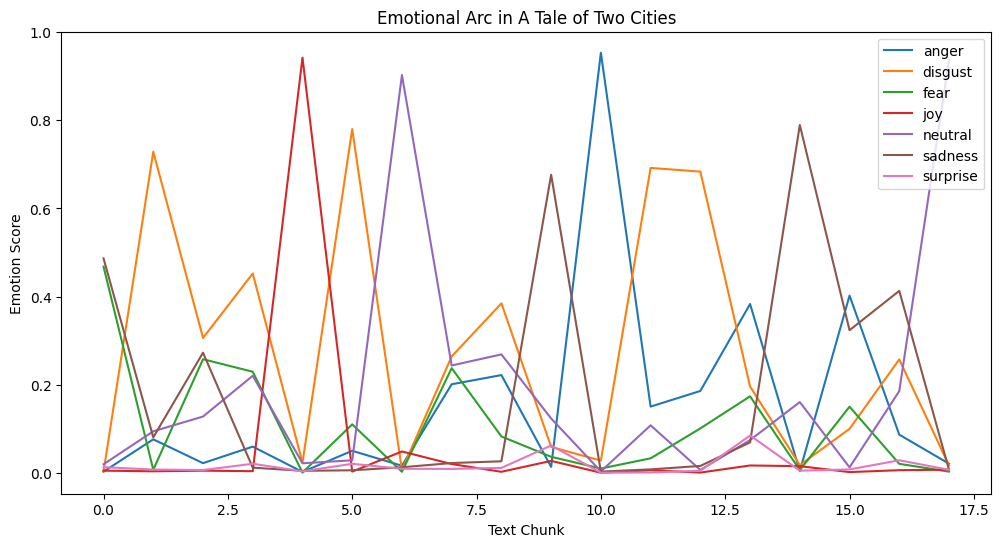

In [37]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)

plt.legend()
plt.title("Emotional Arc in A Tale of Two Cities")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.show()

Total Emotions

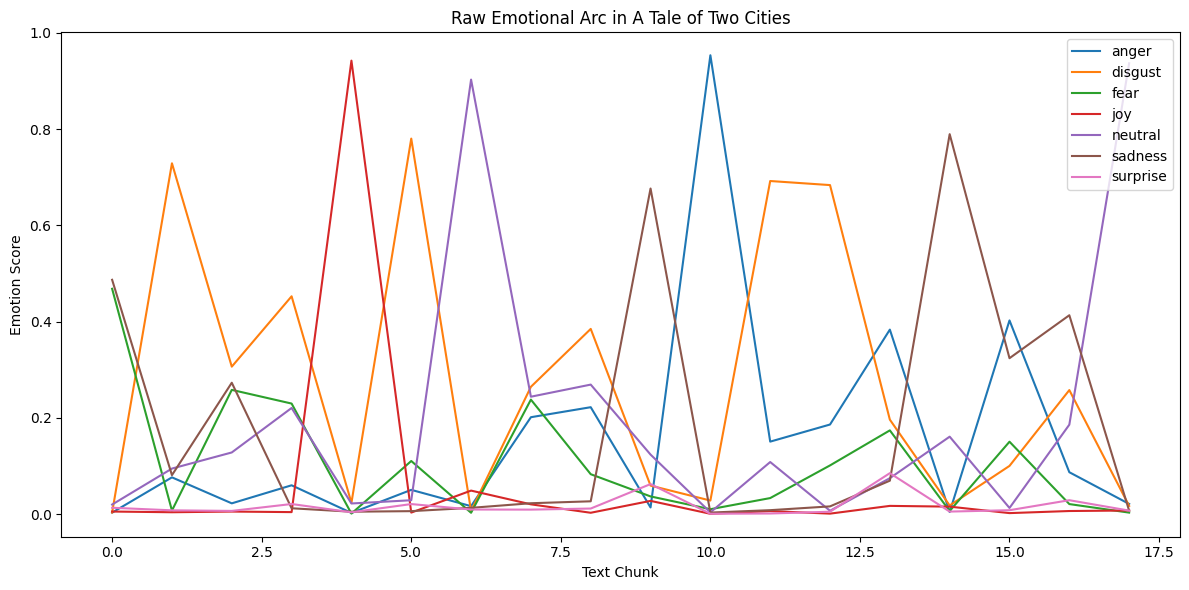

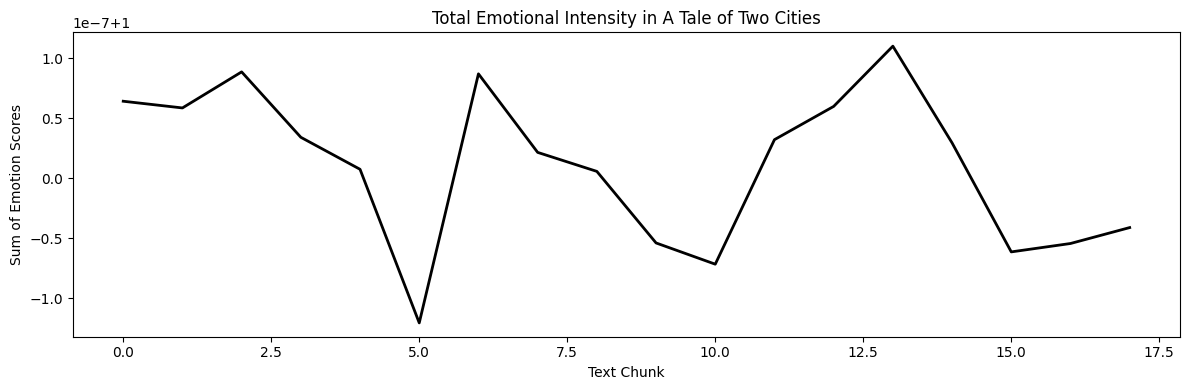

In [38]:
# Analyze emotions in each chunk WITHOUT normalization
emotion_scores = []
for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        score_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(score_dict)
    except Exception as e:
        print(f"Error: {e}")
        continue

# Convert to DataFrame
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Plot individual emotions
plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)
plt.legend()
plt.title("Raw Emotional Arc in A Tale of Two Cities")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.tight_layout()
plt.show()

# ➕ Now sum all raw emotions at each chunk
df["Total_Emotion"] = df.sum(axis=1)

# Plot total emotional intensity
plt.figure(figsize=(12, 4))
plt.plot(df["Total_Emotion"], color="black", linewidth=2)
plt.title("Total Emotional Intensity in A Tale of Two Cities")
plt.xlabel("Text Chunk")
plt.ylabel("Sum of Emotion Scores")
plt.tight_layout()
plt.show()

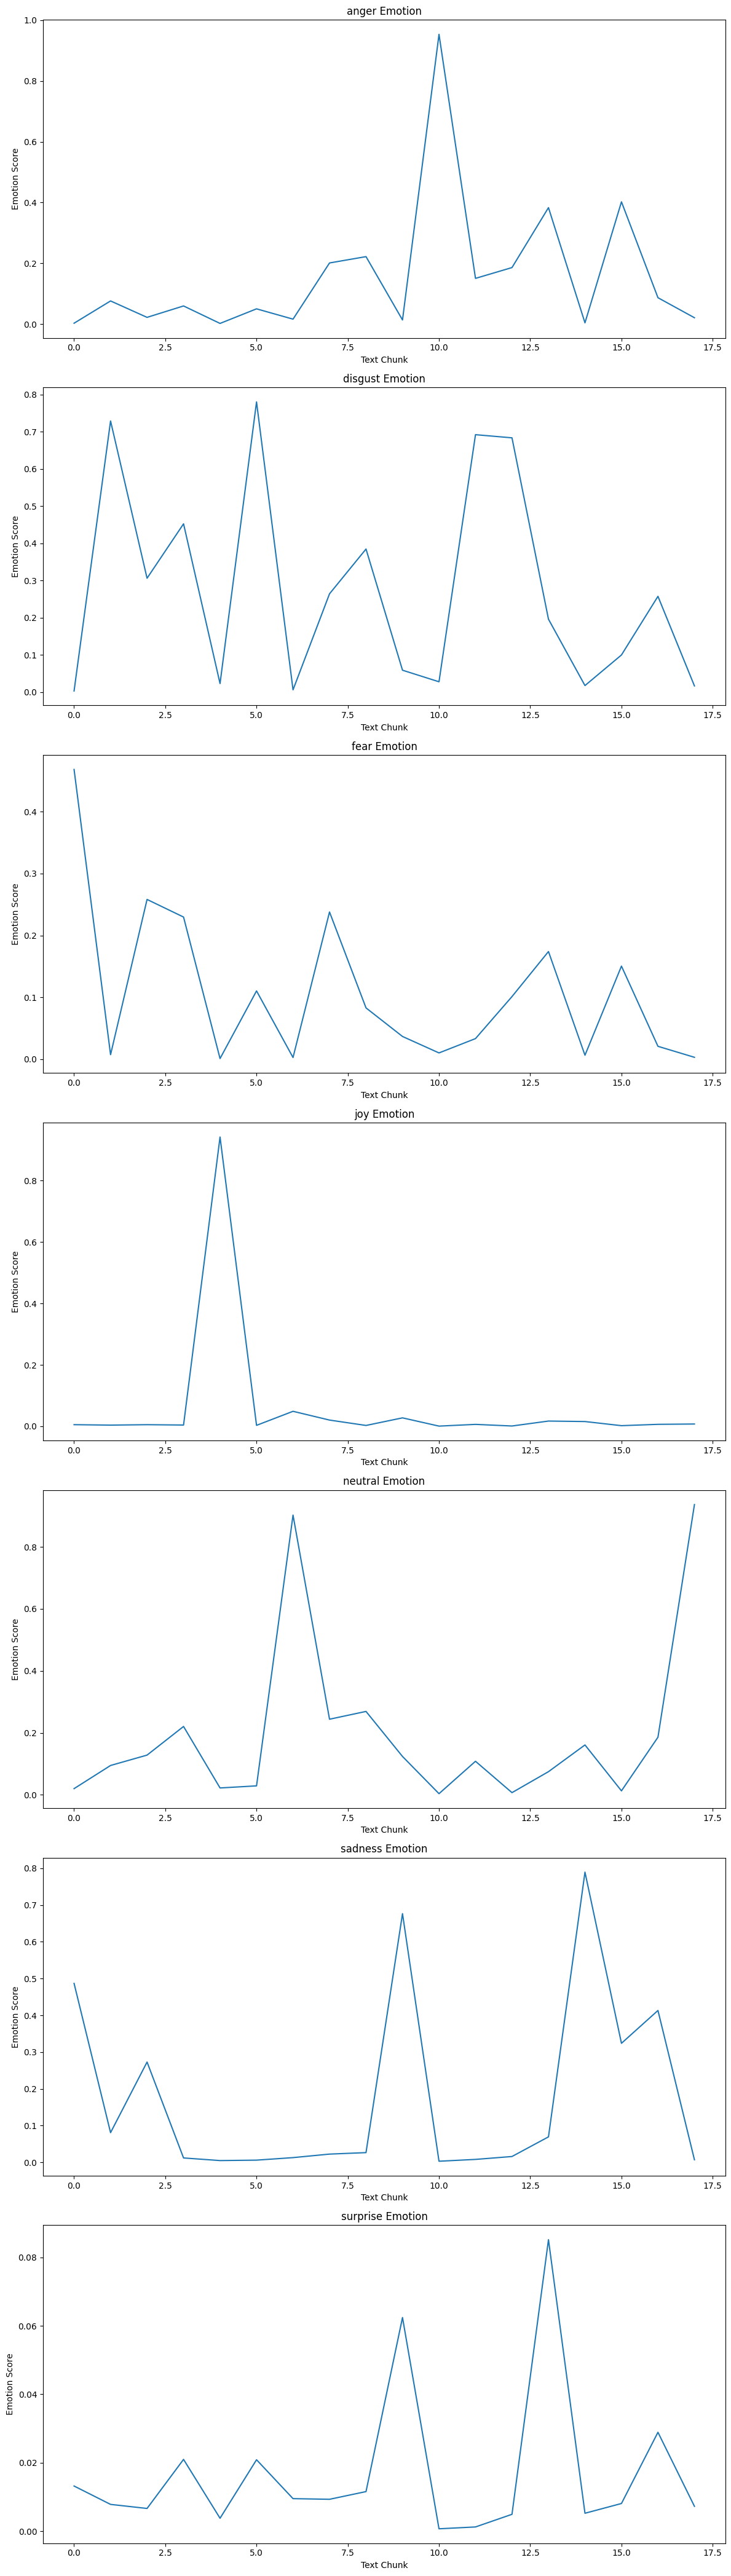

In [39]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Determine the number of emotions
num_emotions = len(df.columns)

# Set up subplots: one for each emotion
fig, axes = plt.subplots(num_emotions, 1, figsize=(12, 6 * num_emotions))

# If there's only one emotion, axes is not an array, so we handle it separately
if num_emotions == 1:
    axes = [axes]

for i, emotion in enumerate(df.columns):
    axes[i].plot(df[emotion])
    axes[i].set_title(f"{emotion} Emotion")
    axes[i].set_xlabel("Text Chunk")
    axes[i].set_ylabel("Emotion Score")

plt.tight_layout()
plt.show()